In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/car-prices-dataset/train.csv
/kaggle/input/car-prices-dataset/test.csv


In [27]:
df=pd.read_csv('/kaggle/input/datasets/zafarali27/car-price-prediction/car_price_prediction_.csv')

In [28]:
df.sample(5)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
111,112,Toyota,2005,4.4,Hybrid,Automatic,64829,Like New,91981.24,Camry
2042,2043,Mercedes,2019,5.9,Electric,Automatic,170881,Used,85817.24,E-Class
1274,1275,Mercedes,2014,5.1,Petrol,Manual,69837,Used,59411.75,GLC
2427,2428,Ford,2000,2.7,Petrol,Manual,22222,New,81902.35,Explorer
2312,2313,Mercedes,2004,2.1,Petrol,Manual,77228,Used,57335.06,C-Class


In [29]:
df.sample(5)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
1545,1546,Tesla,2016,1.5,Electric,Manual,129686,Used,51919.68,Model Y
62,63,Honda,2015,5.0,Diesel,Automatic,119107,New,28379.42,CR-V
1227,1228,Ford,2008,2.5,Hybrid,Automatic,87687,New,72475.92,Fiesta
669,670,Toyota,2012,4.8,Hybrid,Manual,262128,New,14374.69,Camry
1839,1840,Honda,2020,2.0,Electric,Manual,261140,New,47700.62,Civic


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [31]:
df.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [32]:
from scipy import stats

In [34]:
num_cols=df.select_dtypes(include='number').columns
cat_cols=df.select_dtypes(include='object').columns

num_cols = num_cols.drop('Price')

In [35]:
num_cols

Index(['Car ID', 'Year', 'Engine Size', 'Mileage'], dtype='object')

In [36]:
cat_cols

Index(['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model'], dtype='object')

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [38]:
num_preprocessor=Pipeline(steps=[
    ('Scaling',StandardScaler()),
])

cat_preprocessor=Pipeline(steps=[
    ('ordinal_encoding', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])

Here in the categorical columns if the value is ' - ' then it will handle it as -1 

In [39]:
preprocessor=ColumnTransformer(transformers=[
    ('numerical',num_preprocessor,num_cols),
    ('categorical',cat_preprocessor,cat_cols),
    
],remainder='passthrough',verbose_feature_names_out=True)
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('numerical',
                                 Pipeline(steps=[('Scaling',
                                                  StandardScaler())]),
                                 Index(['Car ID', 'Year', 'Engine Size', 'Mileage'], dtype='object')),
                                ('categorical',
                                 Pipeline(steps=[('ordinal_encoding',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 Index(['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model'], dtype='object'))])

In [40]:
x=df.drop(['Price'],axis=1)
y=df['Price']

In [41]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [42]:
x_train_p=preprocessor.fit_transform(x_train)
x_test_p=preprocessor.transform(x_test)
# Scale the target variable/
sc=StandardScaler()
y_train_p=sc.fit_transform(pd.DataFrame(y_train))
y_test_p=sc.transform(pd.DataFrame(y_test))


In [43]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state = 42)

rf.fit(x_train_p, y_train)

y_pred = rf.predict(x_test_p)

from sklearn.metrics import r2_score

print(r2_score(y_test, y_pred))

-0.030949995931923935


# Label encoder is only used for target features and for the trianing features ordinal encoder is used

In [44]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam,RMSprop
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization

In [45]:
x_train_p

array([[ 1.11837081, -0.94002699, -0.04096932, ...,  0.        ,
         1.        ,  5.        ],
       [ 0.98860819, -1.08368513, -1.30264201, ...,  1.        ,
         1.        ,  1.        ],
       [ 0.85470422, -1.37100139,  1.64126094, ...,  1.        ,
         0.        , 19.        ],
       ...,
       [-0.15854851,  0.3528962 , -0.18115517, ...,  1.        ,
         0.        , 25.        ],
       [ 0.06784583, -0.0780782 ,  0.94033167, ...,  1.        ,
         2.        , 11.        ],
       [-0.53127091, -1.22734326,  0.65995996, ...,  0.        ,
         0.        ,  0.        ]])

In [85]:
model=Sequential()

# model.add(Dense(256,activation='relu',input_shape=(x_train_p.shape[1],)))
# model.add(Dropout(0.3))
# BatchNormalization()


model.add(Dense(128,activation='relu',input_shape=(x_train_p.shape[1],),kernel_initializer='glorot_uniform'))

model.add(Dense(64,activation='relu',kernel_initializer='glorot_uniform'))
model.add(Dropout(0.1))
BatchNormalization()

model.add(Dense(32,activation='relu',kernel_initializer='glorot_uniform'))
model.add(Dropout(0.2))
BatchNormalization()

model.add(Dense(1,activation='linear'))



In [86]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
# from keras.utils import plot_model
# plot_model(model)

In [88]:
model.compile(optimizer= Adam(0.01),loss='mean_squared_error',metrics=['r2_score'])

In [89]:
history=model.fit(x_train_p,y_train,batch_size=32,epochs=25,validation_split=0.1,verbose=1)

Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3104932096.0000 - r2_score: -3.0226 - val_loss: 1126030976.0000 - val_r2_score: -0.6210
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1180285824.0000 - r2_score: -0.5411 - val_loss: 928451328.0000 - val_r2_score: -0.3366
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1077779072.0000 - r2_score: -0.4220 - val_loss: 848055936.0000 - val_r2_score: -0.2209
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 968415872.0000 - r2_score: -0.2689 - val_loss: 804382976.0000 - val_r2_score: -0.1580
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 948258880.0000 - r2_score: -0.2917 - val_loss: 794601152.0000 - val_r2_score: -0.1439
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 884812544.0000 - r2_score: -0.2081 - val_loss: 767514048.0000 - val_r2_score: -0.1049
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 903200832.0000 - r2_score: -0.2034 - val_loss: 741770112.0000 - val_r2_sco

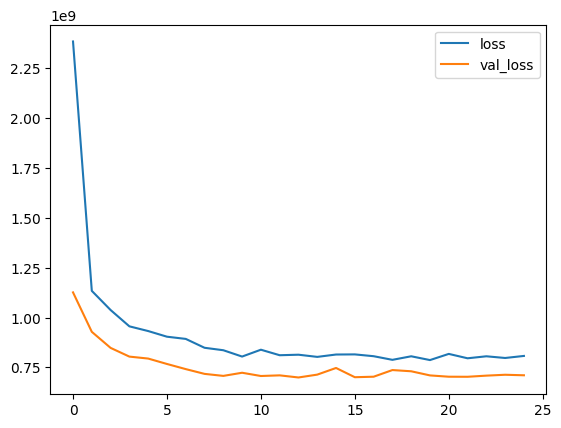

In [90]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()